## Step 0: Initialize
---

In [62]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL13::INSTR', 'ASRL15::INSTR')

In [2]:
rm.list_resources()

('ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL13::INSTR', 'ASRL15::INSTR')

In [63]:
import time
import numpy as np
from typing import *
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from src.DieTesterInstrument import *
from src.FirstLightController import *
from src.ChipAlignmentController import ChipAlignmentController
from src.NIDAQPowermeter import PowermeterSystem
from src.SoftwareFence import SoftwareFence


In [64]:
#@ Die Tester Stage and Powermeter + Motion I/O

try:
    stg.close()
    pm.close()
    time.sleep(1)
    del stg
    del pm
except:
    0
#stg = DieTesterStage(7, 6, 8, 10)
stg = DieTesterStage(13, 15, 5, 4)
pm = PowermeterSystem('Dev1', 5e3)

All stepper motors disconnected
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: NI DAQ, Dev1, USB-6363 (BNC)


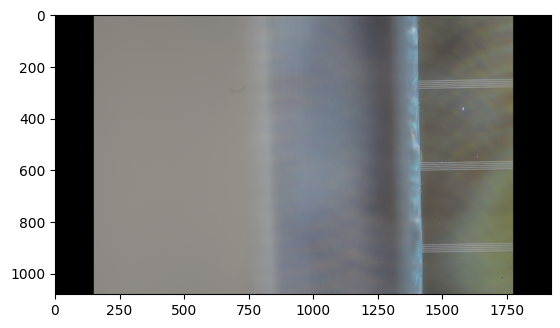

In [65]:
## OBS Virtual Camera (Make sure its on and that you have the correct name)
%matplotlib inline
def clear_interface():
    plt.close('all')
    clear_output(wait=True)

cap = RealtimeVideoCapture(3)  # Change to whatever index your OBS camera is. 
time.sleep(1)

clear_interface()
plt.imshow(cap.mean_capture(10, convert_to_grayscale=False))
plt.show()

In [66]:
flc = FirstLightController(pm, stg)
cac = ChipAlignmentController(stg, cap)
fence = SoftwareFence(stg, cap)

In [ ]:
## Home the axes and set the origin. You won't need to (or want to do this) unless the controllers are power-cycled.
# WARNING: Make sure that the ThorLabs fiber chucks are sufficiently out of the way so as to not collide anything when homing.

#stg.dev1.initialize()  # Left XY
#stg.dev2.initialize()  # Right XY
#stg.dev4.initialize()  # Left and Right Z

# stg.stop()  # Emergency stop

## Step 1: Move Fibers and Chip to Safe Positions
---

In [7]:
## Resist the urge to manually turn the stepper screws. This will mess up the origin location and hence absolute positioning.

In [72]:
## Enter whatever commands you need to do this
stg.set_speed('r', 9)
stg.move_relative('r', 'z', -1000, wait=True)

In [73]:
# Save safe positions (or at least print them out).
l_safe_position = stg.query_position('l')
print(l_safe_position)
r_safe_position = stg.query_position('r')
print(r_safe_position)

(5036.0, 5200.0, -341.9)
(5546.45, 4600.0, 4387.45)


## Step 2: Chip Alignment
---

In [105]:
## Move chip (and camera) so that the top or bottom calibration patterns are visible in the camera, roughly in the middle.
stg.set_speed('m', 9)
stg.move_relative('m', 'X', -10000, wait=True)

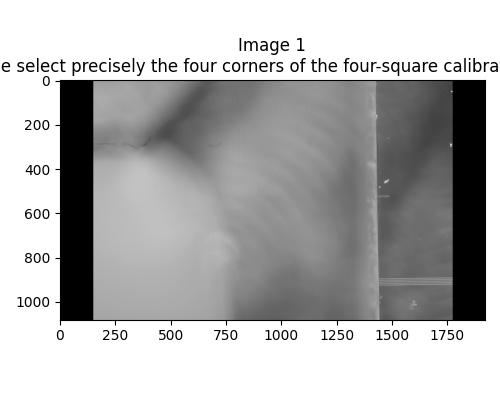

In [92]:
## Run to open template selection widget and draw a bounding box around the pattern.
%matplotlib widget

img = cap.mean_capture(20)
clear_interface()
cac.new_template_selection(img)

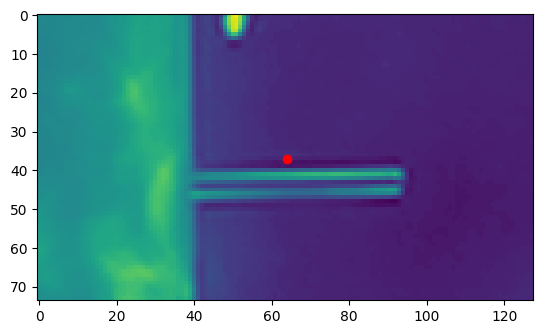

In [96]:
## Save the template to the alignment controller
%matplotlib inline

template_image = cac.generate_template(img)
clear_interface()
plt.imshow(template_image)
plt.scatter(template_image.shape[1] / 2, template_image.shape[0] / 2, c='r')
plt.show()

Starting Calibration Movement...
Calibration movement done. Starting main movement...
All images aquired. Moving back to starting position.
Matching calibration centers...
Generating visualization of calibration centers...
Calculating rotation...
Done. Optimal rotation is -0.0094 degrees.


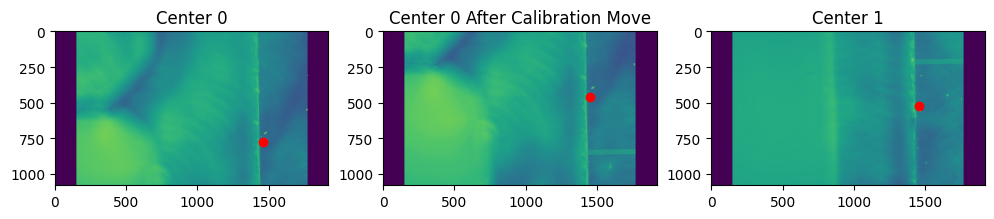

In [101]:
%matplotlib inline
## Select your movement values and perform chip alignment.
# Large movement should be roughly the length of the chip (1 cm works well), small calibration movement should be a few hundred microns.
#   - Make sure that the small movement doesn't bring your calibration pattern out of frame
# The sign of the movements should be positive for moving from top to bottom, and negative for moving bottom to top.


mainX = 10_000  # main movement (width of chip)
calX = 500  # calibration movement
deg = cac.run_angle_calibration(mainX, calX, camera_focus_prompt=True) 

In [102]:
## If angle seems reasonable, rotate to align chip
# Check the pattern centers in the images for reasonableness
stg.move_relative_rotation(deg)


In [117]:
stg.query_position('m')

(1360.3, -0.4632)

In [ ]:
## Check alignment accuracy
#stg.move_relative('m', 'X', mainX, wait=True)

1
(1, 1)


In [106]:
stg.move_relative('m', 'X', 1000, wait=True)

## Step 3: Coarse Fiber Alignment
---

In [129]:
## Perform this for both the left and right stages. ('l' and 'r')
stage = 'r'
stage

'r'

In [140]:
## Do whatever commands you need to move the left/right fiber into the frame and in focus.
stg.move_relative(stage, 'z', 200, wait=True)


100%|██████████| 10/10 [00:11<00:00,  1.12s/it]


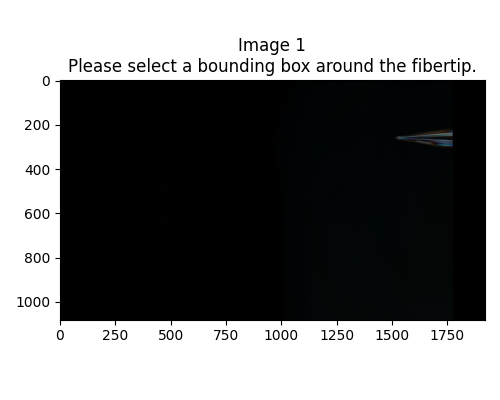

In [141]:
%matplotlib widget
## Make sure the fiber is at least *distance* microns in frame. 
#   - This function will back the fiber out of frame to get a background image, then move it back into frame to start stepping.
#   - Afterwards, choose a template for the fibertip.

distance = 400
extra_backup_distance = 1000
num_steps = 10

clear_interface()
fence.run_calibration(stage, distance, extra_backup_distance, num_steps)


Microns per pixel: 1.556 with MSE of 3.49
Angle of tip with respect to horizontal: 0.015 radians ( 0.88 degrees).


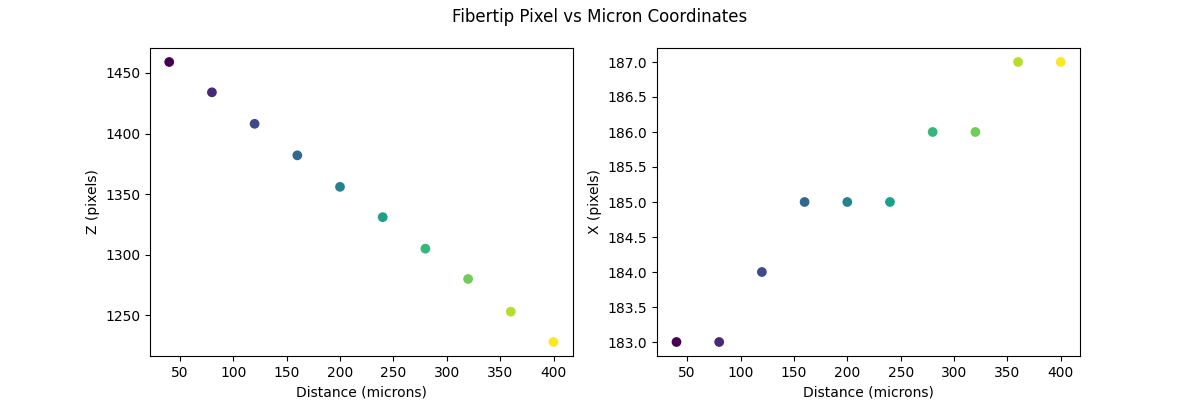

In [142]:
## Calculate the microns per pixel and fibertip angle, and make sure the graphs (and values) seam reasonable.
#   - For the Macro, we've been getting around 1.57 microns per pixel.
result = fence.calculate_calibration(stage)
mpp = result['microns_per_pixel']
tip_angle = result['tip_angle']

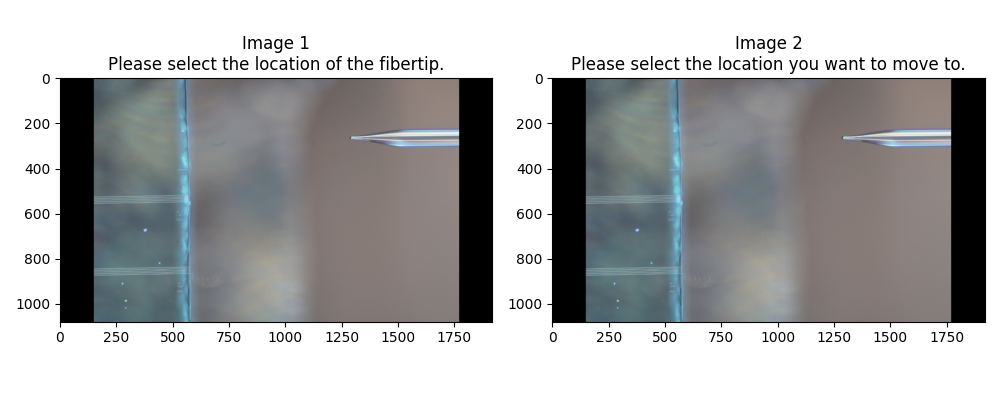

In [143]:
## With the calibration done, now we can move the fiber a few tens of microns away from the desired waveguide.
clear_interface()
fig = fence.new_movement_selection()

In [144]:
## Calculate the move; Make sure it seems reasonable (signs are correct, distances match, etc.)
move = fence.calculate_move(stage, mpp,  tip_angle)  # in coordinates X, Z
move

array([-436.01193297, 1038.77930985])

In [145]:
## Hold your breath... and move!
stg.move_relative(stage, 'X', move[0])
stg.move_relative(stage, 'Z', move[1])


In [149]:
## Manual fine alignment
stg.move_relative(stage, 'X', -10)


In [ ]:
## After you've aligned both fibers to the correct waveguide, you can move on.

## Step 4: First Light
---

In [150]:
import importlib
import src.FirstLightController
importlib.reload(src.FirstLightController)
from src.FirstLightController import *

flc = FirstLightController(pm, stg)

In [276]:
## Manual fine adjustment
# Focus on getting the Y close to alignment.
# stg.move_relative('r', 'Y', 10)

In [151]:
## Y fine-tuning
stage = 'l'
line_numbers = [0, 1, 2] # left XY, right XY, all Z
speed = 4

# Enter a list of relative commands manually
commands = [
    ['Y', -10],
    ['Y', 10],
]
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

datapoints = result['datapoints']
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]

fig.show()

Starting motion...


Current Move: (Y, 10.0): 100%|██████████| 2/2 [00:00<00:00,  2.51item/s]


Returning to original position...


In [ ]:
stg.move_relative('stage', 'Y', max_point[0])

In [416]:
stg.move_relative('r', 'z',-1)

In [467]:
### Broad scan
stage = 'r'
line_numbers = [0, 1, 2]    # motion i/o for left XY, right XY, all Z (works assuming both fibers don't move at the same time)
speed = 7                  # Speed setting from 0-9. Higher is only faster to a point.

commands = flc.pgen.generate_linear_spiral((10, 10), 20)    # params are scan dimension (should be x,y) and number of steps.
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = True)

datapoints = result['datapoints']
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]
print(f"Maximum: {max_point}")

fig.show()

Starting motion...


Current Move: (Y, -10.0): 100%|██████████| 40/40 [00:07<00:00,  5.56item/s]


Returning to original position...
Fitting gaussian regression to datapoints...
Found optimal parameters.
Mean: [0.35067168 0.94510538]
Cov: [[2.63655065 0.13887079]
 [0.13887079 2.80676219]]
Maximum: [0.09677419 1.        ]


In [560]:
# Move to the gaussian fit mean
mean = result['mean']
stg.move_relative(stage, 'X', mean[0])
stg.move_relative(stage, 'Y', mean[1])
print(f"Moved to {mean}")

# Move to the maximum point.
# stg.move_relative(stage, 'X', max_point[0])
# stg.move_relative(stage, 'Y', max_point[1])

Moved to [0.36584212 0.23670205]


In [53]:
np.pi * (0.5e-2)**2/(2 * np.pi * (10e-2)**2)

0.0012499999999999998

In [559]:
### Small Scan
### Covariance should be around 1.2 and 1.3 
stage = 'l'
line_numbers = [0, 1, 2]    # motion i/o for left XY, right XY, all Z (works assuming both fibers don't move at the same time)
speed = 6                   # Speed setting from 0-9. Higher is only faster to a point.

commands = flc.pgen.generate_linear_spiral((5, 5), 10)    # params are scan dimension (should be x,y) and num_steps.
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = True)

datapoints = result['datapoints']
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]
print(f"Maximum: {max_point}")

fig.show()

Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  5.58item/s]


Returning to original position...
Fitting gaussian regression to datapoints...
Found optimal parameters.
Mean: [0.36584212 0.23670205]
Cov: [[ 1.78801424 -0.06673548]
 [-0.06673548  1.35680761]]
Maximum: [0.5        0.43888889]


In [414]:
np.sqrt(2.5/300/0.5)

np.float64(0.12909944487358055)

In [411]:
## Move to the gaussian fit mean
mean = result['mean']
stg.move_relative(stage, 'X', mean[0])
stg.move_relative(stage, 'Y', mean[1])
print(f"Moved stage {stage} to {mean}")

## Move to the maximum point.
# stg.move_relative(stage, 'X', max_point[0])
# stg.move_relative(stage, 'Y', max_point[1])

1
(1, -1)
-1
(1, -1)
Moved stage r to [ 0.13142177 -0.29225516]


In [561]:
## Z fine-tuning
stage = 'l'
line_numbers = [0, 1, 2] # left XY, right XY, all Z
speed = 2

# Enter a list of relative commands manually
commands = [
    ['Z', 2],
    ['Z', -8],
]
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

datapoints = result['datapoints']
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]

fig.show()

Starting motion...


Current Move: (Z, -8.0): 100%|██████████| 2/2 [00:02<00:00,  1.10s/item]


Returning to original position...


In [ ]:
stg.move_relative('r', 'Z', -500)

In [388]:
# stg.move_relative('m', 'x', -11.5)
stg.move_relative('l', 'z', 2)

1
(1, 1)


In [ ]:
## Move to the where the slope of the gaussian is maximum (for vibration testing)
# stage = 'r'
# cov = result['cov']
# a = np.sqrt(cov[0,0])
# stg.set_speed(stage, 3)
# stg.move_relative(stage, 'X', a)

In [222]:
stage = 'r'
stg.set_speed(stage, 9)
stg.move_relative(stage, 'Z', -5000)